In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.2 MB/s eta 0:00:00


In [ ]:
import osmnx as ox

In [ ]:
G = ox.graph_from_place(
    "Guwahati, Assam, India",
    network_type="drive"
)

In [ ]:
roads = ox.graph_to_gdfs(G, nodes=False, edges=True)

In [ ]:
roads.head()


osmid     highway  oneway reversed  \
u         v           key                                            
566643822 2328418250  0     508686097  trunk_link    True    False   
          12968777150 0     224011429    tertiary   False    False   
566643823 2328418248  0      44638826   secondary   False     True   
          11982707863 0    1118012912       trunk    True    False   
566644049 4972479607  0      44638826   secondary   False    False   

                               length  \
u         v           key               
566643822 2328418250  0     12.790274   
          12968777150 0    402.748499   
566643823 2328418248  0     17.694733   
          11982707863 0    991.041803   
566644049 4972479607  0     49.249169   

                                                                    geometry  \
u         v           key                                                      
566643822 2328418250  0    LINESTRING (91.67624 26.15561, 91.67624 26.15549)   
          12968777150 0    LINESTRING (91.67624 26.15561, 91.67635 26.155...   
566643823 2328418248  0     LINESTRING (91.67633 26.1553, 91.67624 26.15517)   
          11982707863 0    LINESTRING (91.67633 26.1553, 91.67638 26.1551...   
566644049 4972479607  0    LINESTRING (91.67075 26.14969, 91.67096 26.149...   

                                                     name   ref lanes  \
u         v           key                                               
566643822 2328418250  0                               NaN   NaN   NaN   
          12968777150 0                               NaN   NaN   NaN   
566643823 2328418248  0    Assam Engineering College Road   NaN   NaN   
          11982707863 0                               NaN  NH27   NaN   
566644049 4972479607  0    Assam Engineering College Road   NaN   NaN   

                          maxspeed tunnel bridge junction access  
u         v           key                                         
566643822 2328418250  0        NaN    NaN    NaN      NaN    NaN  
          12968777150 0        NaN    NaN    NaN      NaN    NaN  
566643823 2328418248  0        NaN    NaN    NaN      NaN    NaN  
          11982707863 0        NaN    NaN    NaN      NaN    NaN  
566644049 4972479607  0        NaN    NaN    NaN      NaN    NaN

In [ ]:
roads.to_file(
    "guwahati_roads.gpkg",
    layer="roads",
    driver="GPKG"
)

In [ ]:
roads.drop(columns="geometry").to_csv(
    "guwahati_roads.csv",
    index=False
)

In [ ]:
roads.head()

osmid     highway  oneway reversed  \
u         v           key                                            
566643822 2328418250  0     508686097  trunk_link    True    False   
          12968777150 0     224011429    tertiary   False    False   
566643823 2328418248  0      44638826   secondary   False     True   
          11982707863 0    1118012912       trunk    True    False   
566644049 4972479607  0      44638826   secondary   False    False   

                               length  \
u         v           key               
566643822 2328418250  0     12.790274   
          12968777150 0    402.748499   
566643823 2328418248  0     17.694733   
          11982707863 0    991.041803   
566644049 4972479607  0     49.249169   

                                                                    geometry  \
u         v           key                                                      
566643822 2328418250  0    LINESTRING (91.67624 26.15561, 91.67624 26.15549)   
          12968777150 0    LINESTRING (91.67624 26.15561, 91.67635 26.155...   
566643823 2328418248  0     LINESTRING (91.67633 26.1553, 91.67624 26.15517)   
          11982707863 0    LINESTRING (91.67633 26.1553, 91.67638 26.1551...   
566644049 4972479607  0    LINESTRING (91.67075 26.14969, 91.67096 26.149...   

                                                     name   ref lanes  \
u         v           key                                               
566643822 2328418250  0                               NaN   NaN   NaN   
          12968777150 0                               NaN   NaN   NaN   
566643823 2328418248  0    Assam Engineering College Road   NaN   NaN   
          11982707863 0                               NaN  NH27   NaN   
566644049 4972479607  0    Assam Engineering College Road   NaN   NaN   

                          maxspeed tunnel bridge junction access  
u         v           key                                         
566643822 2328418250  0        NaN    NaN    NaN      NaN    NaN  
          12968777150 0        NaN    NaN    NaN      NaN    NaN  
566643823 2328418248  0        NaN    NaN    NaN      NaN    NaN  
          11982707863 0        NaN    NaN    NaN      NaN    NaN  
566644049 4972479607  0        NaN    NaN    NaN      NaN    NaN

Total road length in Guwahati: 1295.38 km


<Axes: >

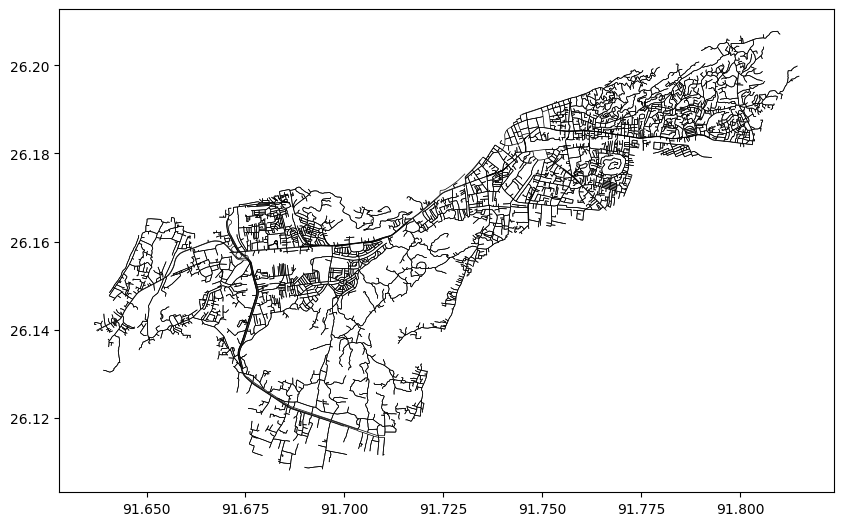

In [ ]:
total_length_km = roads['length'].sum() / 1000
print(f"Total road length in Guwahati: {total_length_km:.2f} km")

# Plotting the road network
roads.plot(figsize=(10, 10), linewidth=0.5, edgecolor='black')

In [ ]:
import pandas as pd

# Some highway records can contain lists (e.g. ['residential', 'unclassified'])
# We must convert them to strings so they are hashable for grouping
roads_clean = roads.copy()
roads_clean["highway"] = roads_clean["highway"].apply(lambda x: ", ".join(x) if isinstance(x, list) else str(x))

# Group roads by highway classification to see distributions
road_summary = (
    roads_clean.groupby("highway")["length"]
    .agg(["count", "sum"])
    .rename(columns={"count": "road_segments", "sum": "total_length_m"})
)

# Calculate length in kilometers and percentage share
road_summary["total_length_km"] = road_summary["total_length_m"] / 1000
total_system_length = road_summary["total_length_km"].sum()
road_summary["percentage_share"] = (road_summary["total_length_km"] / total_system_length) * 100
road_summary = road_summary.sort_values(by="total_length_km", ascending=False)

display(road_summary)

,road_segments,total_length_m,total_length_km,percentage_share
highway,,,,
residential,9703,995450.499910,995.450500,76.846153
tertiary,1026,122569.544513,122.569545,9.462046
unclassified,346,56294.096333,56.294096,4.345756
secondary,492,42066.095944,42.066096,3.247392
primary,235,41093.972851,41.093973,3.172346
trunk,74,23678.936065,23.678936,1.827951
living_street,42,4414.851805,4.414852,0.340815
trunk_link,22,3860.327712,3.860328,0.298007
"unclassified, residential",10,2831.754173,2.831754,0.218604


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.3 MB/s eta 0:00:00
Guwahati road network downloaded successfully.
Number of roads: 11987

Total Road Length by Highway Classification:
                            total_length_km
highway                                    
residential                      995.450500
tertiary                         122.569545
unclassified                      56.294096
secondary                         42.066096
primary                           41.093973
trunk                             23.678936
living_street                      4.414852
trunk_link                         3.860328
residential, unclassified          2.831754
tertiary_link                      2.470053
residential, living_street         0.471364
primary_link                       0.127621
secondary_link                     0.051933


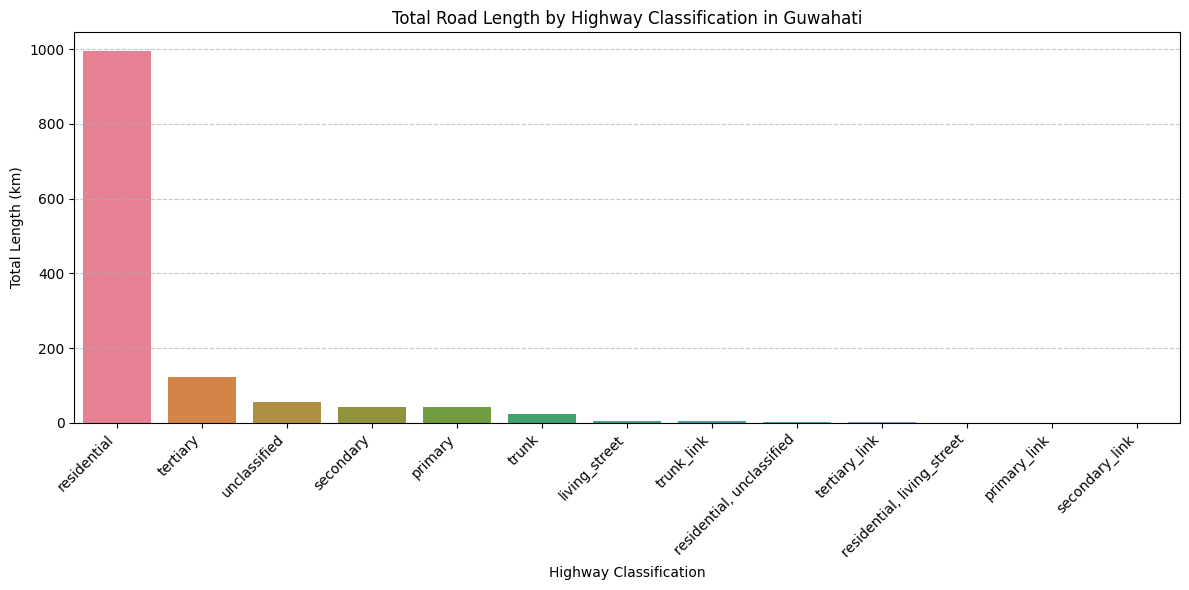

In [ ]:

# Install OSMnx if needed
!pip install osmnx -q

# Import libraries
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Get Guwahati road network
# --------------------------------------------------

place = "Guwahati, Assam, India"

G = ox.graph_from_place(
    place,
    network_type="drive",
    simplify=True
)

print("Guwahati road network downloaded successfully.")

# --------------------------------------------------
# 2. Convert network into road GeoDataFrame
# --------------------------------------------------

nodes, roads = ox.graph_to_gdfs(G)

print("Number of roads:", len(roads))

# --------------------------------------------------
# 3. Clean highway classification
# --------------------------------------------------

roads_clean = roads.copy()

roads_clean["highway"] = roads_clean["highway"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
)

# --------------------------------------------------
# 4. Calculate total road length
# --------------------------------------------------

road_summary = (
    roads_clean
    .groupby("highway")["length"]
    .sum()
    .div(1000)
    .sort_values(ascending=False)
    .to_frame("total_length_km")
)

# --------------------------------------------------
# 5. Display road summary
# --------------------------------------------------

print("\nTotal Road Length by Highway Classification:")
print(road_summary)

# --------------------------------------------------
# 6. Plot graph
# --------------------------------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=road_summary.reset_index(),
    x="highway",
    y="total_length_km",
    hue="highway",
    legend=False
)

plt.title("Total Road Length by Highway Classification in Guwahati")
plt.xlabel("Highway Classification")
plt.ylabel("Total Length (km)")

plt.xticks(rotation=45, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

In [ ]:
print(roads.shape)
print(roads.columns.tolist())
roads.head()

(11987, 14)
['osmid', 'highway', 'oneway', 'reversed', 'length', 'geometry', 'name', 'ref', 'lanes', 'maxspeed', 'tunnel', 'bridge', 'junction', 'access']


osmid     highway  oneway reversed  \
u         v           key                                            
566643822 2328418250  0     508686097  trunk_link    True    False   
          12968777150 0     224011429    tertiary   False    False   
566643823 2328418248  0      44638826   secondary   False     True   
          11982707863 0    1118012912       trunk    True    False   
566644049 4972479607  0      44638826   secondary   False    False   

                               length  \
u         v           key               
566643822 2328418250  0     12.790274   
          12968777150 0    402.748499   
566643823 2328418248  0     17.694733   
          11982707863 0    991.041803   
566644049 4972479607  0     49.249169   

                                                                    geometry  \
u         v           key                                                      
566643822 2328418250  0    LINESTRING (91.67624 26.15561, 91.67624 26.15549)   
          12968777150 0    LINESTRING (91.67624 26.15561, 91.67635 26.155...   
566643823 2328418248  0     LINESTRING (91.67633 26.1553, 91.67624 26.15517)   
          11982707863 0    LINESTRING (91.67633 26.1553, 91.67638 26.1551...   
566644049 4972479607  0    LINESTRING (91.67075 26.14969, 91.67096 26.149...   

                                                     name   ref lanes  \
u         v           key                                               
566643822 2328418250  0                               NaN   NaN   NaN   
          12968777150 0                               NaN   NaN   NaN   
566643823 2328418248  0    Assam Engineering College Road   NaN   NaN   
          11982707863 0                               NaN  NH27   NaN   
566644049 4972479607  0    Assam Engineering College Road   NaN   NaN   

                          maxspeed tunnel bridge junction access  
u         v           key                                         
566643822 2328418250  0        NaN    NaN    NaN      NaN    NaN  
          12968777150 0        NaN    NaN    NaN      NaN    NaN  
566643823 2328418248  0        NaN    NaN    NaN      NaN    NaN  
          11982707863 0        NaN    NaN    NaN      NaN    NaN  
566644049 4972479607  0        NaN    NaN    NaN      NaN    NaN

In [ ]:
roads.to_csv(
    "/content/road_data.csv",
    index=False
)

print("Road dataset saved!")

Road dataset saved!


In [ ]:
roads.to_file(
    "/content/road_data.gpkg",
    layer="roads",
    driver="GPKG"
)